In [30]:
import numpy as np
from astropy.modeling.models import Gaussian2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.wcs import utils
import astropy.units as u
from astropy import wcs
from astropy.io import fits
from astropy.nddata.utils import Cutout2D
import matplotlib.pyplot as plt
from reproject import reproject_interp, reproject_adaptive
from matplotlib.colors import LogNorm, Normalize

from astropy.visualization import simple_norm
from scipy.ndimage import gaussian_filter
import os
import matplotlib as mpl
import glob
os.chdir('../')
import filaments as fo
from filaments.utils import custom_colormap

In [10]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 18}
mpl.rc('font', **font)

In [7]:
y, x = np.mgrid[0:500, 0:500]
data = Gaussian2D(1, 50, 100, 10, 5, theta=0.5)(x, y)

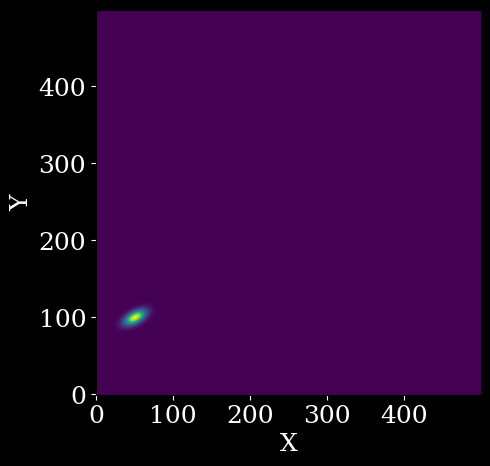

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
fig.set_facecolor('black')
ax.imshow(data, origin='lower')
fo.set_labels(ax, 'X', 'Y')
fo.set_as_white(ax)
plt.rcParams['axes.facecolor']='k'

In [16]:
position = SkyCoord('13h11m29.96s -01d19m18.7s', frame='icrs')
wcs = WCS(naxis=2)
wcs.wcs.ctype = ['RA---SIN', 'DEC--SIN']
wcs.wcs.crval = [position.ra.to_value(u.deg),
                 position.dec.to_value(u.deg)]
wcs.wcs.crpix = [50, 100] # refernece pixel wrt the original image
original_hdu = wcs.to_header()
original_hdu

WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                 50.0 / Pixel coordinate of reference point            
CRPIX2  =                100.0 / Pixel coordinate of reference point            
CDELT1  =                  1.0 / [deg] Coordinate increment at reference point  
CDELT2  =                  1.0 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'                / Units of coordinate increment and value        
CTYPE1  = 'RA---SIN'           / Right ascension, orthographic/synthesis project
CTYPE2  = 'DEC--SIN'           / Declination, orthographic/synthesis projection 
CRVAL1  =      197.87483333333 / [deg] Coordinate value at reference point      
CRVAL2  =     -1.3218611111111 / [deg] Coordinate value at reference point      
LONPOLE =                180.0 / [deg] Native longitude of celestial pole       
LATPOLE =     -1.32186111111

In [17]:
ra, dec = position.ra.to_value(u.deg), position.dec.to_value(u.deg)
print(f"ra = {ra:.2f}, dec = {dec:.2f}")
print(f"max val in the data is {np.max(data)}")

ra = 197.87, dec = -1.32
max val in the data is 1.0


(50, 50)


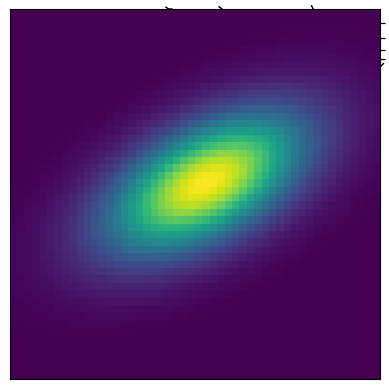

In [18]:
cutout = Cutout2D(data, position, (50, 50), wcs=wcs)
ax = plt.subplot(1,1,1, projection=WCS(original_hdu))
ax.imshow(cutout.data, origin='lower')  
ax.coords['ra'].set_axislabel('Right Ascension')
ax.coords['dec'].set_axislabel('Declination')

print(np.shape(cutout.data))

In [7]:
def define_header_wcs(data, coord, crpix, cdelt):
    cutout_hdu = fits.PrimaryHDU(data)
    cutout_hdu.header['CRPIX1'] = crpix[0]
    cutout_hdu.header['CRPIX2'] = crpix[1]
    cutout_hdu.header['CDELT1'] = cdelt[0]
    cutout_hdu.header['CDELT2'] = cdelt[1]
    cutout_hdu.header['CRVAL1'] = coord[0]
    cutout_hdu.header['CRVAL2'] = coord[1]
    cutout_hdu.header['CTYPE1'] = 'RA---SIN'
    cutout_hdu.header['CTYPE2'] = 'DEC--SIN'
    cutout_hdu.header['CUNIT1'] = 'deg'
    cutout_hdu.header['CUNIT2'] = 'deg'
    cutout_wcs = WCS(cutout_hdu.header)
    cutout_header = cutout_hdu.header
    return cutout_header, cutout_wcs

new_ra, new_dec = 140, -3.5
cutout_header, cutout_wcs = define_header_wcs(cutout.data, [new_ra, new_dec], [25, 25], [1, 1])

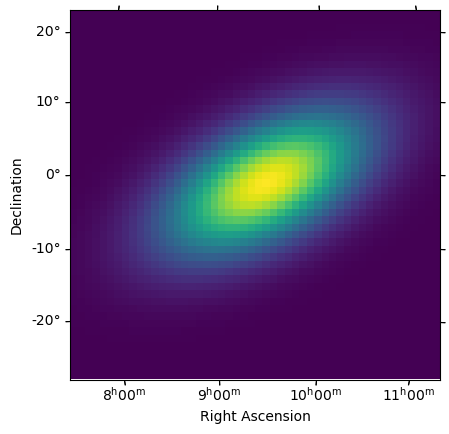

In [8]:
ax = plt.subplot(1,1,1, projection=WCS(cutout_header))
ax.imshow(cutout.data, origin='lower')  
ax.coords['ra'].set_axislabel('Right Ascension')
ax.coords['dec'].set_axislabel('Declination')

In [9]:
npix = np.shape(cutout.data)[0]
reproj_hdu = fits.PrimaryHDU(cutout.data)
reproj_hdu.header = cutout_header
reproj_wcs = WCS(reproj_hdu.header)

# add rotation to the cutout header
rho = np.pi / 3
scale = 1
reproj_wcs.wcs.cd = [[scale*np.cos(rho), -scale*np.sin(rho)],
              [scale*np.sin(rho), scale*np.cos(rho)]]

reproj_header = reproj_hdu.header

In [10]:
reproj_wcs.wcs.cd

array([[ 0.5      , -0.8660254],
       [ 0.8660254,  0.5      ]])

In [11]:
array, footprint = reproject_interp((cutout.data, reproj_wcs), reproj_header, shape_out=(50, 50))

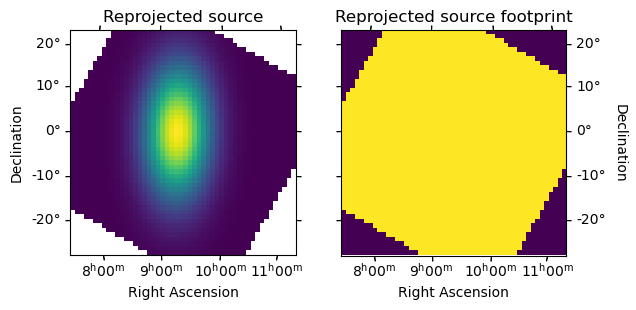

In [12]:
def plot_rotated_image_footprint(array, footprint, reproj_header):
    ax1 = plt.subplot(1,2,1, projection=WCS(reproj_header))
    ax1.imshow(array, origin='lower')
    ax1.coords['ra'].set_axislabel('Right Ascension')
    ax1.coords['dec'].set_axislabel('Declination')
    ax1.set_title('Reprojected source')

    ax2 = plt.subplot(1,2,2, projection=WCS(reproj_header))
    ax2.imshow(footprint, origin='lower')
    ax2.coords['ra'].set_axislabel('Right Ascension')
    ax2.coords['dec'].set_axislabel('Declination')
    ax2.coords['dec'].set_axislabel_position('r')
    ax2.coords['dec'].set_ticklabel_position('r')
    ax2.set_title('Reprojected source footprint')
    return 

plot_rotated_image_footprint(array, footprint, reproj_header)

Text(0.5, 1.0, 'Reprojected source footprint')

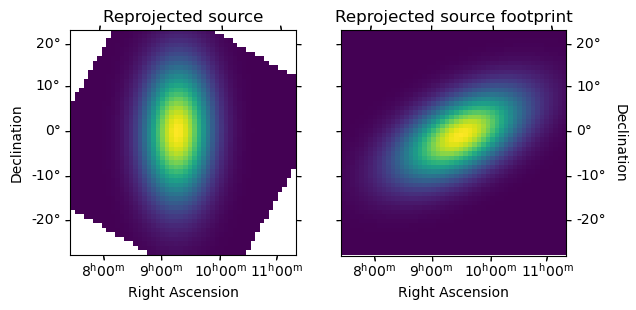

In [13]:
ax1 = plt.subplot(1,2,1, projection=WCS(reproj_header))
ax1.imshow(array, origin='lower')
ax1.coords['ra'].set_axislabel('Right Ascension')
ax1.coords['dec'].set_axislabel('Declination')
ax1.set_title('Reprojected source')

ax2 = plt.subplot(1,2,2, projection=WCS(reproj_header))
ax2.imshow(cutout.data, origin='lower')
ax2.coords['ra'].set_axislabel('Right Ascension')
ax2.coords['dec'].set_axislabel('Declination')
ax2.coords['dec'].set_axislabel_position('r')
ax2.coords['dec'].set_ticklabel_position('r')
ax2.set_title('Reprojected source footprint')

# Moving on to test this on the filament sub-images

In [19]:
hdu_test = fits.open('/he13srv_local/shreeram/eRass_products/lc_north_dis_SD2_s5.0_S001/filid94_len_87.69Mpc_7seg_3.19deg_z0.504/inputs/ima_0.2_2.3_2.fits.gz')
input_data = hdu_test[0].data
utils.proj_plane_pixel_scales(WCS(hdu_test[0].header))

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58862.432384 from DATE-OBS.
Set MJD-END to 59421.880208 from DATE-END'. [astropy.wcs.wcs]


array([0.00111111, 0.00111111])

# Define a simple input WCS

In [20]:
input_wcs = WCS(naxis=2)
input_wcs.wcs.crpix = input_data.shape[0]/2, input_data.shape[1]/2
input_wcs.wcs.cdelt = -0.00111111, 0.00111111
input_header = input_wcs.to_header()
input_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : ''  ''  
CRVAL : 0.0  0.0  
CRPIX : 1620.0  1620.0  
PC1_1 PC1_2  : 1.0  0.0  
PC2_1 PC2_2  : 0.0  1.0  
CDELT : -0.00111111  0.00111111  
NAXIS : 0  0

In [17]:
utils.proj_plane_pixel_scales(input_wcs)

array([0.00111111, 0.00111111])

<AxesSubplot:title={'center':'Original filament sub-image'}, xlabel='x [pixels]', ylabel='y [pixels]'>

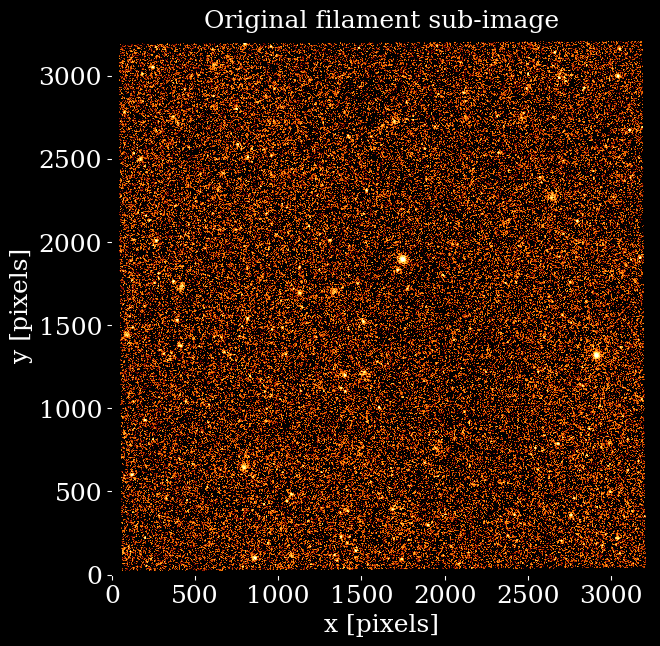

In [22]:
fig = plt.figure(figsize=(7, 7))
fig.set_facecolor('black')
ax = plt.subplot(1,1,1)
norm1 = simple_norm(input_data, 'log', min_cut=1e-2, max_cut=1)
ax.imshow(input_data, origin='lower', cmap='afmhot', norm=norm1)
fo.set_labels(ax, r"x [pixels]", 'y [pixels]', title='Original filament sub-image')
fo.set_as_white(ax)

# Define an output WCS with rotation

In [24]:
cd_matrix = [[0.6387524796345235,  0.7694122885428512  ], [-0.7694122885428512,  0.6387524796345235 ]]

output_wcs = WCS(naxis=2)
output_wcs.wcs.crpix = input_data.shape[0]/2, input_data.shape[1]/2
output_wcs.wcs.cdelt = -0.00111111, 0.00111111
output_wcs.wcs.pc = cd_matrix

In [25]:
result_gaussian, _ = reproject_adaptive((input_data, input_wcs), 
                                        output_wcs, 
                                        shape_out=input_data.shape)

# Plot the original and rotated image

<AxesSubplot:xlabel='x [pixels]', ylabel='y [pixels]'>

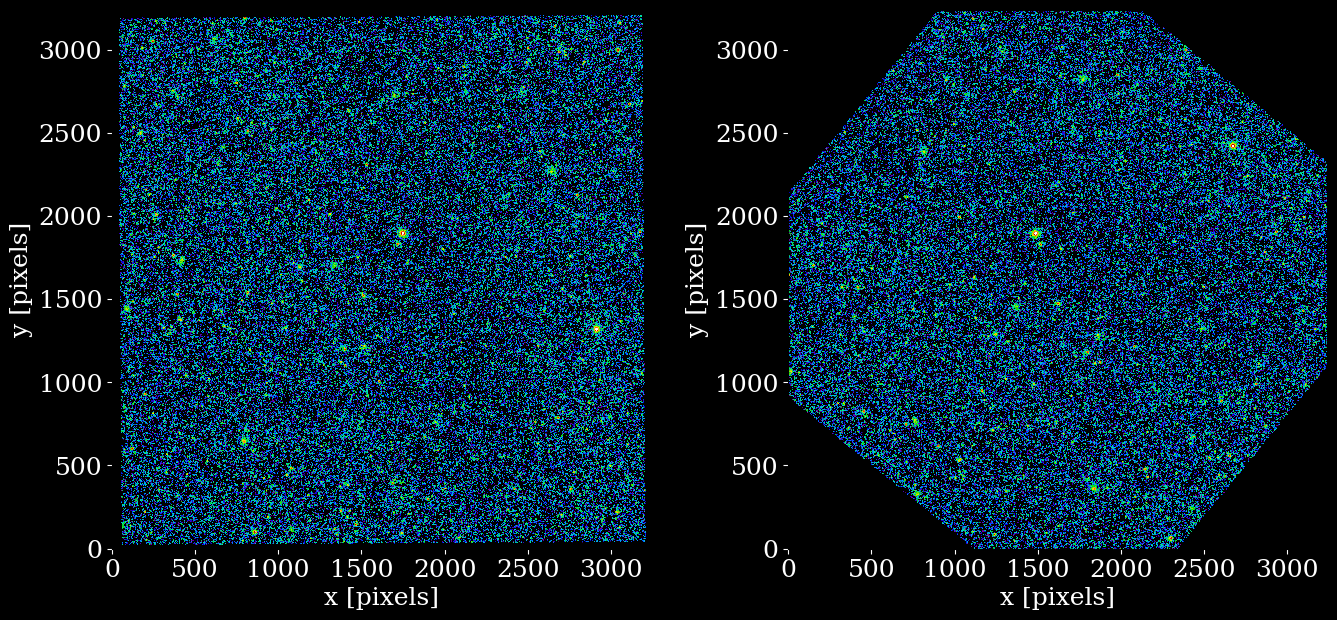

In [59]:
fig = plt.figure(figsize=(16, 7))
fig.set_facecolor('black')

ax1 = plt.subplot(1,2,1)
norm1 = simple_norm(result_gaussian, 'log', min_cut=1e-2, max_cut=2)
ax1.imshow(input_data, origin='lower', cmap=custom_colormap(), norm=norm1)
fo.set_labels(ax1, r"x [pixels]", 'y [pixels]')
fo.set_as_white(ax1)

ax2 = plt.subplot(1,2,2)
norm2 = simple_norm(result_gaussian, 'log', min_cut=1e-2, max_cut=2)
ax2.imshow(result_gaussian, origin='lower', cmap=custom_colormap(), norm=norm2)
fo.set_labels(ax2, r"x [pixels]", 'y [pixels]')
fo.set_as_white(ax2)

# Get cutout from the rotated image

In [28]:
x_ends, y_ends = (1525.4491837433907, 1712.550816256579), (1531.5422299166576, 1706.4577700832908)

In [32]:
custom_colormap

<function filaments.utils.custom_colormap()>

<AxesSubplot:xlabel='x [pixels]', ylabel='y [pixels]'>

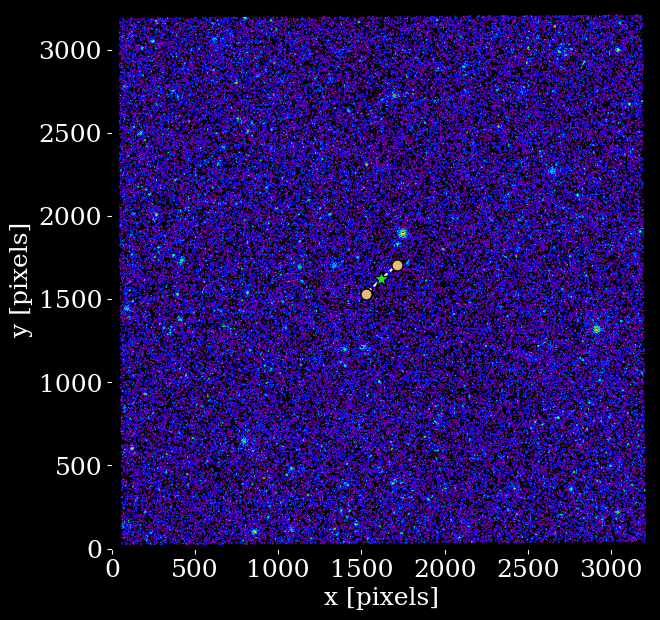

In [46]:
fig = plt.figure(figsize=(7, 7))
fig.set_facecolor('black')

ax1 = plt.subplot(1,1,1)
norm1 = simple_norm(input_data, 'log', min_cut=1e-12, max_cut=10)
ax1.imshow(input_data, origin='lower', cmap=custom_colormap(), norm=norm1)
ax1.plot(x_ends, y_ends, 'w--o', mfc='#e3bd76', ms=8, mec='k')
ax1.plot(1620, 1620, '*', c='#1ae82b', ms=12, mec='k')
fo.set_labels(ax1, r"x [pixels]", 'y [pixels]')
fo.set_as_white(ax1)

In [47]:
size_x = (x_ends[1]-x_ends[0])
size_x

187.1016325131884

In [55]:
cutout_img = Cutout2D(input_data, (1620, 1620), 
                          (input_data.shape[0]-50, size_x))
cutout_rot_img = Cutout2D(result_gaussian, (1620, 1620), 
                          (result_gaussian.shape[0]-20, 255.43178985801092))

<AxesSubplot:xlabel='x [pixels]', ylabel='y [pixels]'>

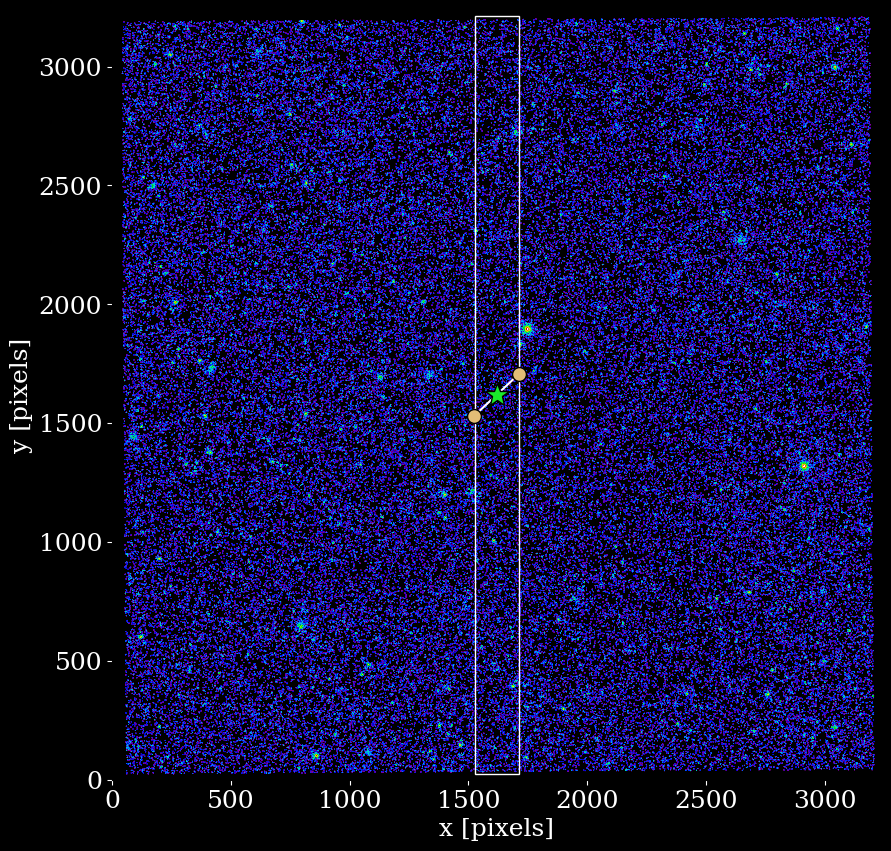

In [70]:
fig = plt.figure(figsize=(10, 10))
#fig.set_facecolor('black')
ax1 = plt.subplot(1,1,1)
norm1 = simple_norm(input_data, 'log', min_cut=1e-12, max_cut=10)
ax1.imshow(input_data, origin='lower', cmap=custom_colormap(), norm=norm1)
ax1.plot(x_ends, y_ends, 'w-o', mfc='#e3bd76', ms=10, mec='k')
ax1.plot(1620, 1620, '*', c='#1ae82b', ms=18, mec='k')
cutout_img.plot_on_original(color='w', lw=1)
fo.set_labels(ax1, r"x [pixels]", 'y [pixels]')
#fo.set_as_white(ax1)

In [62]:
x_ends_new, y_ends_new = [1490.568210141989, 1746.608467634401], [1616.5293059685048, 1623.3008363793424]
1746-1490.568210141989

255.43178985801092

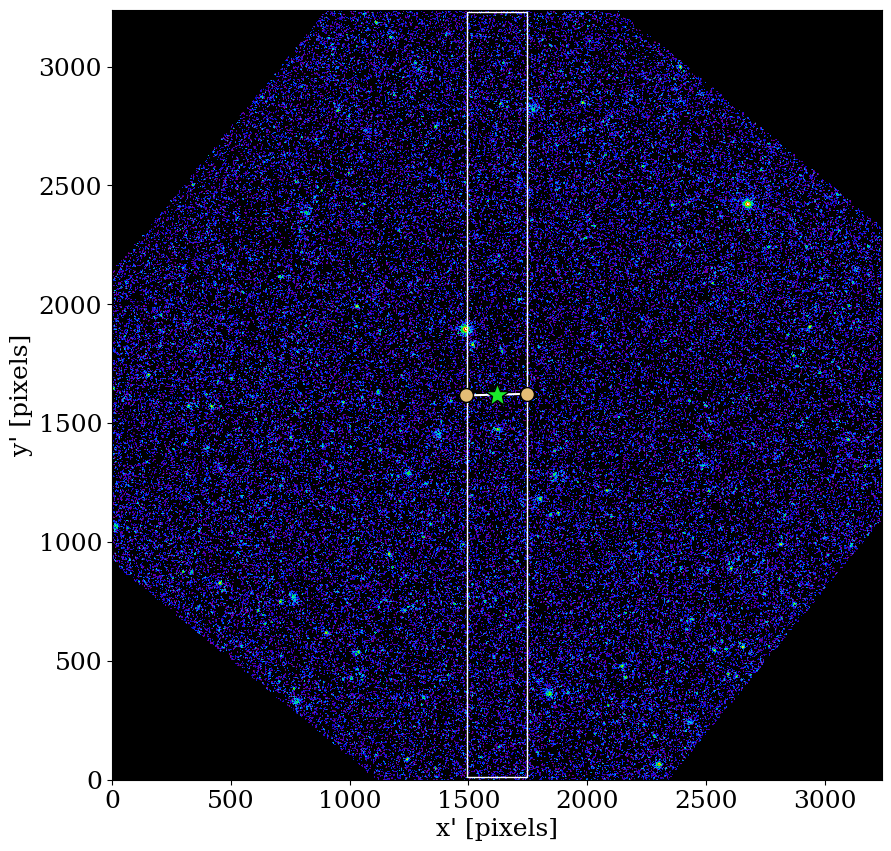

In [74]:
fig = plt.figure(figsize=(10, 10))
ax2 = plt.subplot(1,1,1)
#fig.set_facecolor('black')
norm2 = simple_norm(result_gaussian, 'log', min_cut=1e-2, max_cut=10)
ax2.imshow(result_gaussian, origin='lower', cmap=custom_colormap(), norm=norm2)
ax2.plot(x_ends_new, y_ends_new, 'w-o', mfc='#e3bd76', ms=10, mec='k')
ax2.plot(1620, 1620, '*', c='#1ae82b', ms=18, mec='k')

cutout_rot_img.plot_on_original(color='w', lw=1)
fo.set_labels(ax2, r"x' [pixels]", "y' [pixels]")
#fo.set_as_white(ax2)

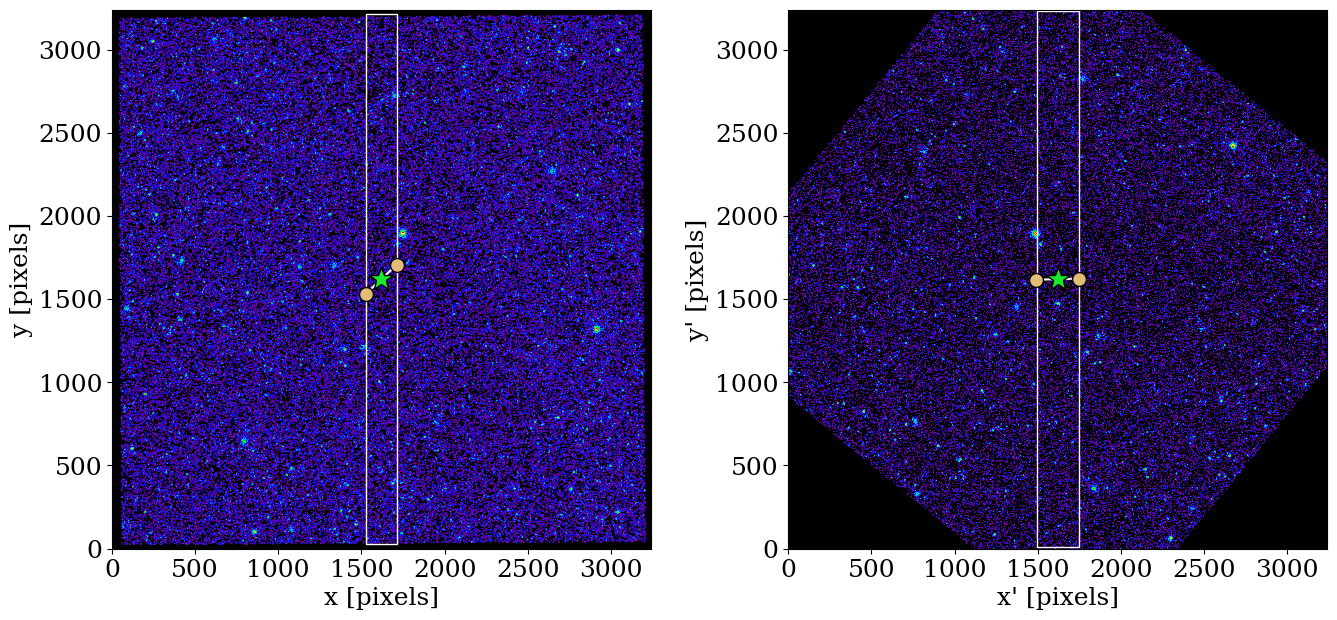

In [76]:
fig = plt.figure(figsize=(16, 7))
#fig.set_facecolor('black')

ax1 = plt.subplot(1,2,1)
norm1 = simple_norm(input_data, 'log', min_cut=1e-12, max_cut=10)
ax1.imshow(input_data, origin='lower', cmap=custom_colormap(), norm=norm1)
ax1.plot(x_ends, y_ends, 'w-o', mfc='#e3bd76', ms=10, mec='k')
ax1.plot(1620, 1620, '*', c='#1ae82b', ms=18, mec='k')
cutout_img.plot_on_original(color='w', lw=1)
fo.set_labels(ax1, r"x [pixels]", 'y [pixels]')
#fo.set_as_white(ax1)

ax2 = plt.subplot(1,2,2)
#fig.set_facecolor('black')
norm2 = simple_norm(result_gaussian, 'log', min_cut=1e-2, max_cut=10)
ax2.imshow(result_gaussian, origin='lower', cmap=custom_colormap(), norm=norm2)
ax2.plot(x_ends_new, y_ends_new, 'w-o', mfc='#e3bd76', ms=10, mec='k')
ax2.plot(1620, 1620, '*', c='#1ae82b', ms=18, mec='k')

cutout_rot_img.plot_on_original(color='w', lw=1)
fo.set_labels(ax2, r"x' [pixels]", "y' [pixels]")
#fo.set_as_white(ax2)